In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from PIL import Image

train_dir = "../../datasets/DevanagariHandwrittenDigitDataset/Train/"
test_dir = "../../datasets/DevanagariHandwrittenDigitDataset/Test/"

img_height, img_width = 28, 28

In [ ]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical
def load_images(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for file in os.listdir(class_path):
            img_path = os.path.join(class_path, file)

            img = Image.open(img_path).convert('L')
            img = img.resize((img_width, img_height))
            img_array = (np.array(img) / 255.0).astype('float32')

            images.append(img_array)
            labels.append(label)
    return np.array(images), np.array(labels)

# Load data
X_train_raw, y_train_raw = load_images(train_dir)
X_test_raw, y_test_raw = load_images(test_dir)

indices = np.arange(X_train_raw.shape[0])
np.random.shuffle(indices)
X_train_raw = X_train_raw[indices]
y_train_raw = y_train_raw[indices]

x_train = X_train_raw.reshape(-1, img_height, img_width, 1)
x_test = X_test_raw.reshape(-1, img_height, img_width, 1)

y_train = to_categorical(y_train_raw, num_classes=10)
y_test = to_categorical(y_test_raw, num_classes=10)

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)

Training data shape: (17000, 28, 28, 1)
Training labels shape: (17000, 10)


##Build Model

In [ ]:
model = Sequential([
    Flatten(input_shape=(img_height, img_width, 1)),
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax') 
])

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

##Model Compilation and training

In [70]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    # Using .keras extension as .h5 is legacy
    ModelCheckpoint("best_devnagari_model.keras", save_best_only=True),
    EarlyStopping(monitor='val_loss', patience=3)
]

history = model.fit(
    x_train, 
    y_train, 
    epochs=20, 
    batch_size=128, 
    validation_split=0.2, 
    callbacks=callbacks
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8275 - loss: 0.5683 - val_accuracy: 0.9438 - val_loss: 0.2001
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9484 - loss: 0.1601 - val_accuracy: 0.9547 - val_loss: 0.1572
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9688 - loss: 0.1036 - val_accuracy: 0.9638 - val_loss: 0.1228
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9780 - loss: 0.0754 - val_accuracy: 0.9671 - val_loss: 0.1149
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9836 - loss: 0.0555 - val_accuracy: 0.9750 - val_loss: 0.0921
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9862 - loss: 0.0434 - val_accuracy: 0.9703 - val_loss: 0.1029
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9921 - loss: 0.0295 - val_accuracy: 0.9771 - val_loss: 0.0858
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9940 - loss: 0.0203 - val_accur

##Evaluation and Prediction

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

predictions = model.predict(x_test)
predicted_label = np.argmax(predictions[0])
true_label = np.argmax(y_test[0])

print("Predicted labels:", predicted_label)
print("True labels:", true_label)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9753 - loss: 0.1102
Test Accuracy: 97.53%
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Predicted labels: 0
True labels: 0


##Save and Load Model

In [73]:
model.save("devnagari_model.h5")

loaded_model = tf.keras.models.load_model("devnagari_model.h5")

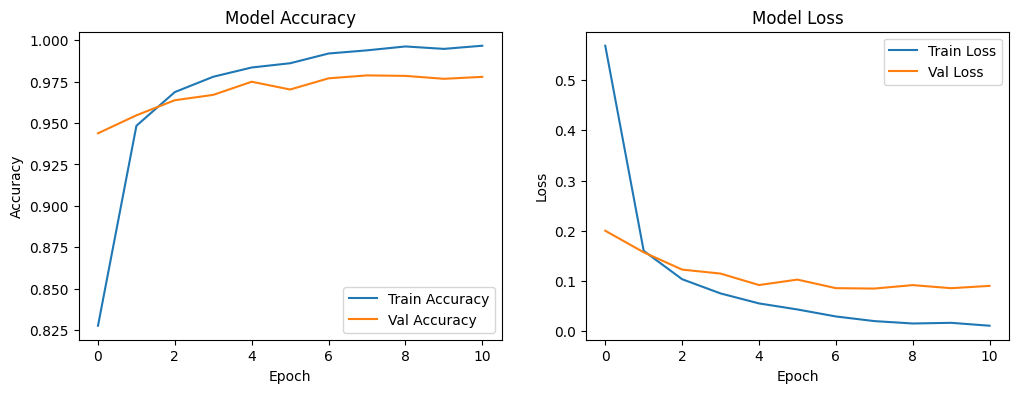

In [75]:
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


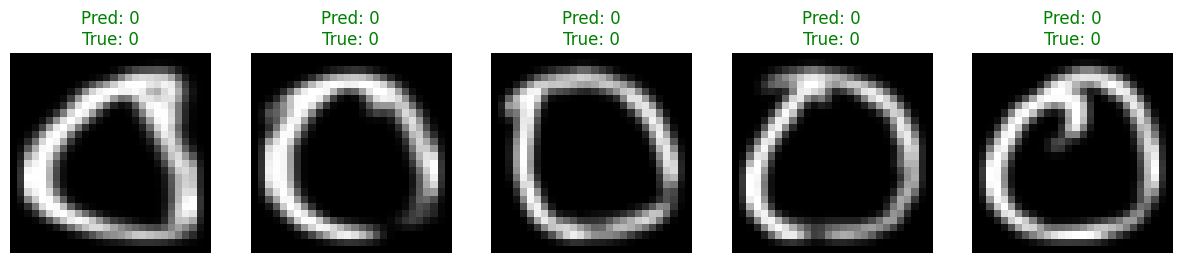

In [76]:
def visualize_predictions(x_test, y_test, model, count=5):
    plt.figure(figsize=(15, 5))
    predictions = model.predict(x_test[:count])
    
    for i in range(count):
        plt.subplot(1, count, i + 1)
        
        plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
        
        pred_label = np.argmax(predictions[i])
        true_label = np.argmax(y_test[i])
        
        color = 'green' if pred_label == true_label else 'red'
        plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
        plt.axis('off')
    
    plt.show()

visualize_predictions(x_test, y_test, model)